Investigate why the DG1 signal for many genes have enriched number of reads in DG1

March 1, 2024

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
from cc_src.reference_data import load_analysis_genes

genes = load_analysis_genes()

In [8]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_rg1_vst_config

Loading MNase reads for YAL067C/SEO1...Loading chromosome reads: 1
Done.


In [49]:
from src.timer import Timer

def get_summed_data(replicate):

    config = load_yl_rg1_vst_config(replicate)
    chromatin_model = ChromatinModel(config)
    chromatin_model.load_mnase_gene('SEO1')
    timer = Timer()

    summed_data = pd.DataFrame(columns=chromatin_model.timepoints, index=genes.index)

    i = 0
    n = len(summed_data)
    for orf_name, row in genes.iterrows():
        chromatin_model.load_mnase_gene(orf_name, log=False)
        chromatin_model.create_deconvolution_bins()
        sum_data = chromatin_model.normalized_bins.sum(axis=1).sum(axis=1)
        summed_data.loc[orf_name] = sum_data
        if i % 100 == 0:
            print(f"{i}/{n} - {timer.get_time()}")

        i += 1
    return summed_data

summed_data1 = get_summed_data(1)

 ...]

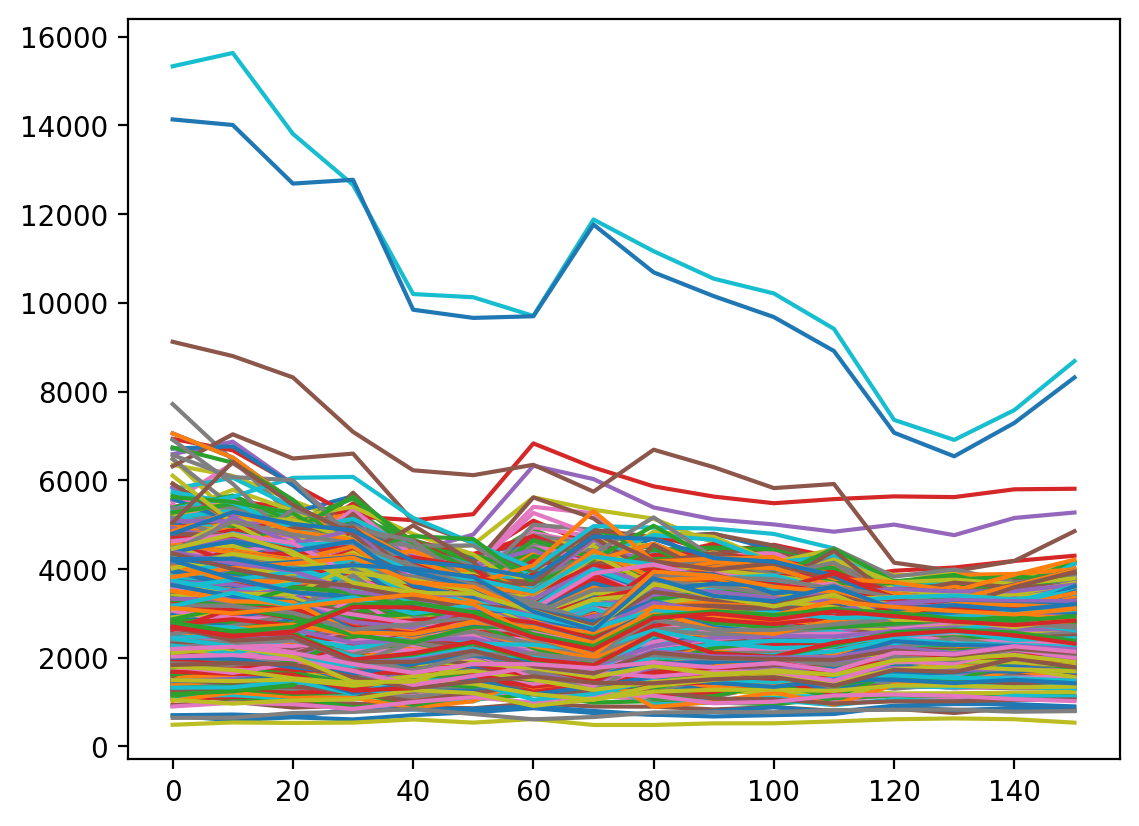

In [ ]:
plt.plot(summed_data.dropna().T)
plt.plot(summed_data.dropna().sum(axis=0))
0

In [ ]:
summed_data2 = get_summed_data(2)

Loading MNase reads for YAL067C/SEO1...Loading chromosome reads: 1
Done.
0/5584 - 00:00:00.32
100/5584 - 00:00:37.54
200/5584 - 00:01:18.18
300/5584 - 00:01:58.77
400/5584 - 00:02:39.85
500/5584 - 00:03:20.54
600/5584 - 00:03:52.39
700/5584 - 00:04:52.02
800/5584 - 00:05:45.99
900/5584 - 00:06:40.20
1000/5584 - 00:07:34.54
1100/5584 - 00:08:28.54
1200/5584 - 00:09:22.04
1300/5584 - 00:10:15.93
1400/5584 - 00:11:04.74
1500/5584 - 00:11:42.24
1600/5584 - 00:12:22.95
1700/5584 - 00:12:58.78
1800/5584 - 00:13:49.00
1900/5584 - 00:14:39.19
2000/5584 - 00:15:33.60
2100/5584 - 00:16:21.08
2200/5584 - 00:17:08.92
2300/5584 - 00:17:56.20
2400/5584 - 00:18:34.97
2500/5584 - 00:19:13.85
2600/5584 - 00:19:48.11
2700/5584 - 00:20:27.19
2800/5584 - 00:21:06.95
2900/5584 - 00:21:46.70
3000/5584 - 00:22:26.51
3100/5584 - 00:23:11.51
3200/5584 - 00:23:56.31
3300/5584 - 00:24:35.73
3400/5584 - 00:25:30.39
3500/5584 - 00:26:20.61
3600/5584 - 00:27:10.96
3700/5584 - 00:28:01.09
3800/5584 - 00:28:51.11
390